In [ ]:
# Colab에서 한글 폰트 설정을 위한 코드
!apt-get update -qq # apt 패키지 리스트 업데이트
!apt-get install -y fonts-nanum # 나눔 폰트 설치

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔바른고딕 폰트 경로
fm.fontManager.addfont(fontpath) # 폰트 매니저에 폰트 추가
plt.rcParams['font.family'] = 'NanumBarunGothic' # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("한글 폰트 'NanumBarunGothic'이(가) 설정되었습니다.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 118 not upgraded.
한글 폰트 'NanumBarunGothic'이(가) 설정되었습니다.


In [ ]:
import pandas as pd
data_url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(data_url)
print(f"Dataset loaded successfully from: {data_url}")

Dataset loaded successfully from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# 단순 선형 회귀

In [ ]:
# W, b 수동으로 구하기
import numpy as np

age = df["age"].values
charges = df["charges"].values

# W, b 계산
x_mean = np.mean(age)
y_mean = np.mean(charges)

w_manual = np.sum((age - x_mean) * (charges - y_mean)) / np.sum((age - x_mean) ** 2)
b_manual = y_mean - w_manual * x_mean

# 결과 확인
print("Manual OLS calculation")
print(f"\tSlope(W): {w_manual}")
print(f"\tIntercept(b): {b_manual}")

Manual OLS calculation
	Slope(W): 257.7226186668955
	Intercept(b): 3165.885006063025


In [ ]:
from sklearn.linear_model import LinearRegression

# Linear Regression 으로 학습
age_reshaped = age.reshape(-1, 1)
model = LinearRegression()
model.fit(age_reshaped, charges)

w_sklearn = model.coef_[0]
b_sklearn = model.intercept_

# 결과 확인
print("Scikit-learn Linear Regression")
print(f"\tSlope(W): {w_sklearn:.4f}")
print(f"\tIntercept(b): {b_sklearn:.4f}")

Scikit-learn Linear Regression
	Slope(W): 257.7226
	Intercept(b): 3165.8850


In [ ]:
# 결과 비교
is_w_close = np.isclose(w_manual, w_sklearn)
is_b_close = np.isclose(b_manual, b_sklearn)

print("Comparison")
print(f"\tSlope(W) Comparison: {is_w_close}")
print(f"\tIntercept(W) Comparison: {is_b_close}")

Comparison
	Slope(W) Comparison: True
	Intercept(W) Comparison: True


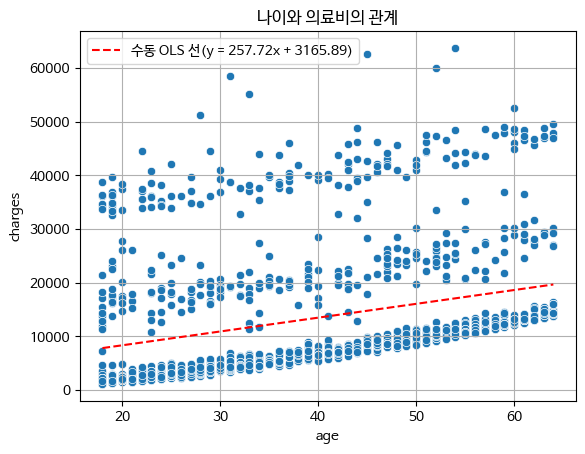

In [ ]:
import seaborn as sns

sns.scatterplot(x="age", y="charges", data=df)
plt.title("나이와 의료비의 관계")

# 회귀선 추가
x_line = np.array([age.min(), age.max()])
y_line_manual = w_manual * x_line + b_manual

plt.plot(x_line, y_line_manual, color="red", linestyle="--",
         label=f"수동 OLS 선(y = {w_manual:.2f}x + {b_manual:.2f})")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 회귀 모델 평가

def calc_mse(actual, predicted):
  return np.mean((actual - predicted) ** 2)

# MSE 계산
predicted_charges_manual = w_manual * age + b_manual
mse_manual = calc_mse(charges, predicted_charges_manual)
print(f"MSE 결과 값 - w: {w_manual:.2f} / b: {b_manual:.2f} / MSE: {mse_manual:.2f}")

MSE 결과 값 - w: 257.72 / b: 3165.89 / MSE: 133440978.61


In [ ]:
# 다양한 시나리오 적용
varied_scope = [0, 100, 500]

for w_var in varied_scope:
  predicted_charge_varied = w_var * age + b_manual
  mse_varied = calc_mse(charges, predicted_charge_varied)
  print(f"MSE for w = {w_var} / b: {b_manual:.2f} / MSE: {mse_varied:.2f}")

MSE for w = 0 / b: 3165.89 / MSE: 248644439.71
MSE for w = 100 / b: 3165.89 / MSE: 176587760.98
MSE for w = 500 / b: 3165.89 / MSE: 235249984.75


# 다중회귀 (Multiple Linear Regression)

- (정의): 다중 회귀는 여러 개의 독립 변수(feature)를 사용하여 하나의 결과 값(target)을 예측하는 회귀 분석 방법입니다.

- (목적): 여러 변수 간의 관계를 동시에 고려하여 보다 정확한 예측과 변수의 영향력 분석을 수행하는 것입니다.

In [ ]:
from sklearn.model_selection import train_test_split

# categorical -> 숫자로 변환
df = pd.get_dummies(df, drop_first=True)

X = df.drop("charges", axis=1) # 독립변수
y = df["charges"] # 종속변수

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)
print("train data size: ", X_train.shape)
print("test data size: ", X_test.shape)

train data size:  (1070, 8)
test data size:  (268, 8)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

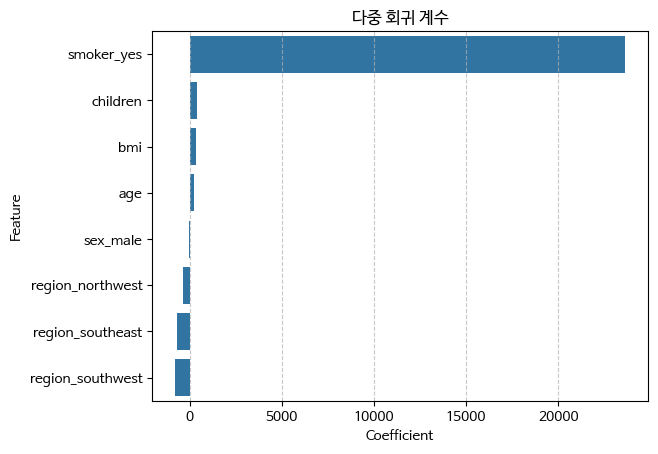

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train) # 모델 학습

feature_names = X_train.columns
coefficients = model.coef_

coeff_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
coeff_df = coeff_df.sort_values(by="Coefficient", ascending=False)

# 시각화
sns.barplot(x="Coefficient", y="Feature", data=coeff_df)
plt.title("다중 회귀 계수")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

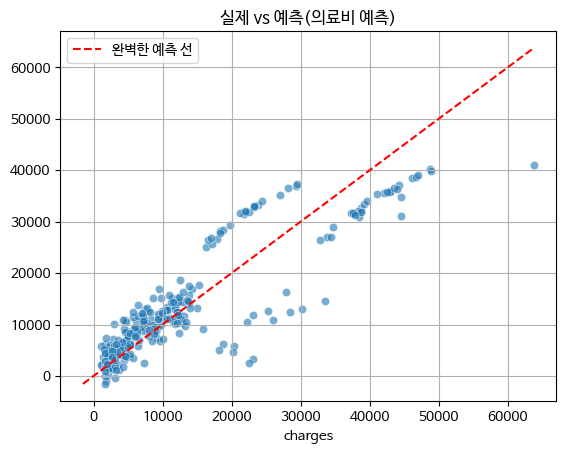

In [ ]:
# 테스트 데이터를 이용한 모델 평가
y_pred = model.predict(X_test)

# 실제값과 예측값을 비교
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.title("실제 vs 예측(의료비 예측)")

# 대각선 생성 <- "실제값 = 예측값"이면 대각선이 그려짐
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--",
         label="완벽한 예측 선")
plt.legend()
plt.grid(True)
plt.show()

## 다양한 회귀 알고리즘 학습

- (목적): 여러 회귀 알고리즘을 학습시켜 같은 데이터에서 모델별 예측 성능을 비교하기 위함입니다.

- (사용한 모델):
  - Linear Regression: 기본적인 선형 회귀 모델로, 변수와 결과 값 사이의 선형 관계를 학습합니다.
  - Ridge Regression: L2 규제를 사용하는 선형 회귀 모델로, 과적합을 방지하기 위해 계수의 크기를 제한합니다.
  - Lasso Regression: L1 규제를 사용하는 선형 회귀 모델로, 중요하지 않은 변수의 계수를 0으로 만들어 변수 선택 효과가 있습니다.
  - Decision Tree Regressor: 데이터를 여러 조건으로 분할하여 **트리 구조로 예측하는 모델입니다.
  - Random Forest Regressor: 여러 개의 Decision Tree를 결합한 앙상블 모델로, 더 안정적이고 정확한 예측을 제공합니다.

- (핵심): 다양한 알고리즘을 학습시켜 데이터에 가장 적합한 모델을 찾는 과정이 머신러닝 모델링에서 중요합니다.


In [ ]:
# ==================================================
# 다양한 회귀 알고리즘 학습
# ==================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 모델 생성
lr_model = LinearRegression()
ridge_model = Ridge()
lasso_model = Lasso()
dt_model = DecisionTreeRegressor()
rf_model = RandomForestRegressor()

# 모델 학습
lr_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("All 5 regression models have been trained successfully")

All 5 regression models have been trained successfully


In [ ]:
# ==================================================
# 다양한 회귀 알고리즘 결과 비교
# ==================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 모델 별 예측 진행
y_pred_lr = lr_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# 각 모델별 반복을 위해 자료구조 만들기
predictions = {
    "Linear Regression": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

# 각 모델별로 MAE, MSE, RMSE 계산
results = []
for model_name, y_pred in predictions.items():
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  results.append({"Model": model_name, "MAE": mae, "MSE": mse, "RMSE": rmse})

# 결과를 저장한 데이터프레임 생성
eval_df = pd.DataFrame(results)
print(eval_df.round(2))

               Model      MAE          MSE     RMSE
0  Linear Regression  4181.19  33596915.85  5796.28
1              Ridge  4193.59  33645037.09  5800.43
2              Lasso  4182.43  33605507.55  5797.03
3      Decision Tree  3146.64  42762031.73  6539.27
4      Random Forest  2570.00  21102860.32  4593.78


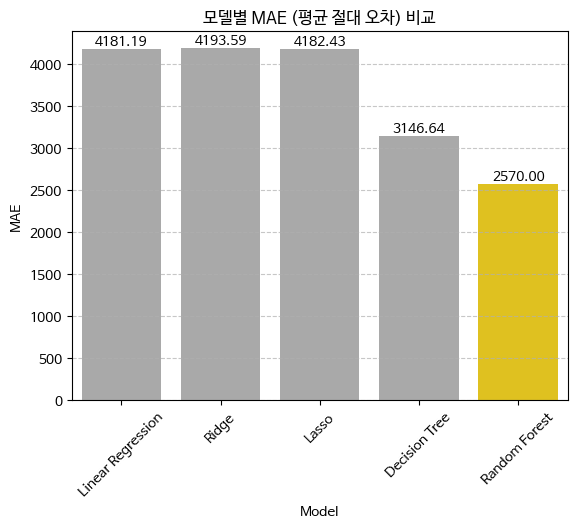

In [ ]:
# MAE가 가장 낮은 모델 찾기

best_mae_model = eval_df.loc[eval_df["MAE"].idxmin()]

sns.barplot(x="Model", y="MAE", hue="Model", data=eval_df,
            palette = ["#FFD700" if m == best_mae_model["Model"] else "#A9A9A9"
                      for m in eval_df["Model"]]
            )

plt.title("모델별 MAE (평균 절대 오차) 비교")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 막대 위 수치 표시
for index, row in eval_df.iterrows():
  plt.text(index, row["MAE"], f"{row['MAE']:.2f}",
           color="black", ha="center", va="bottom")

plt.show()

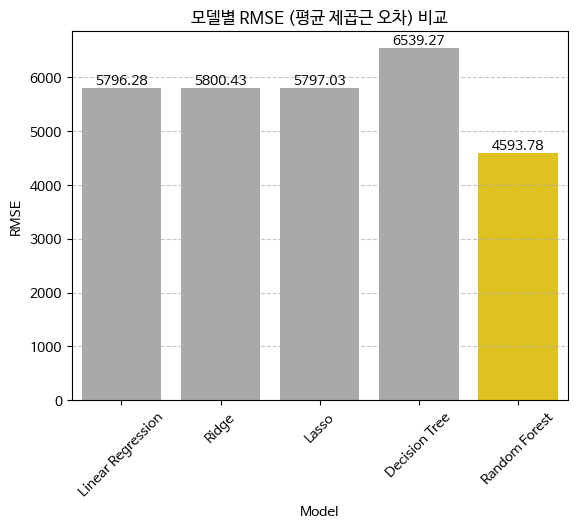

In [ ]:
# RMSE가 가장 낮은 모델 찾기

best_rmse_model = eval_df.loc[eval_df["RMSE"].idxmin()]

sns.barplot(x="Model", y="RMSE", hue="Model", data=eval_df,
            palette = ["#FFD700" if m == best_rmse_model["Model"] else "#A9A9A9"
                      for m in eval_df["Model"]]
            )

plt.title("모델별 RMSE (평균 제곱근 오차) 비교")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 막대 위 수치 표시
for index, row in eval_df.iterrows():
  plt.text(index, row["RMSE"], f"{row['RMSE']:.2f}",
           color="black", ha="center", va="bottom")

plt.show()

In [ ]:
# 가장 성능이 좋은 모델의 예측값 선택 (여기서는 Random Forest)
best_model_name = eval_df.loc[eval_df['MAE'].idxmin()]['Model']

if best_model_name == 'Linear Regression':
    y_pred_best = y_pred_lr
elif best_model_name == 'Ridge':
    y_pred_best = y_pred_ridge
elif best_model_name == 'Lasso':
    y_pred_best = y_pred_lasso
elif best_model_name == 'Decision Tree':
    y_pred_best = y_pred_dt
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
else:
    y_pred_best = y_pred_rf # 기본값으로 Random Forest 설정

# 가장 성능이 좋은 모델의 MAE 값 가져오기
best_mae = eval_df.loc[eval_df["Model"] == best_model_name, "MAE"].values[0]

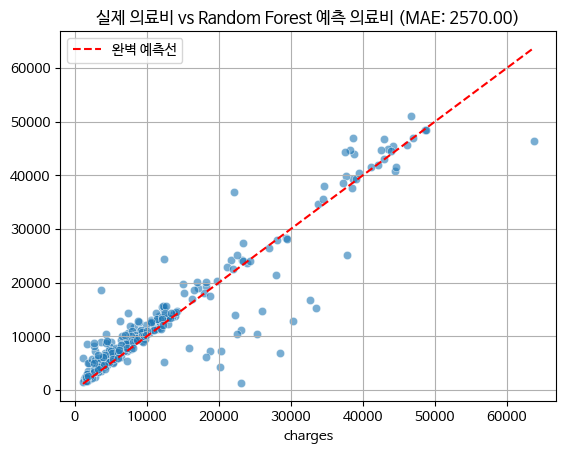

In [ ]:
# 산점도
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6)
plt.title(f"실제 의료비 vs {best_model_name} 예측 의료비 (MAE: {best_mae:.2f})")

# 45도 대각선 추가
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--",
         label="완벽 예측선")
plt.legend()
plt.grid(True)
plt.show()

# Session 4: 실습 결과 해석 (요약)
## 1. Random Forest가 가장 낮은 MAE

- (Random Forest 성능 우수): Random Forest Regressor의 MAE가 2545.21로 가장 낮게 나타났습니다.
- (의미): 실제 의료비와 예측값의 평균 오차가 가장 작아 가장 정확한 예측 모델로 확인되었습니다.

## 2. 선형 모델 vs 트리 모델 성능 차이

- (선형 모델 성능): Linear Regression, Ridge, Lasso는 MAE 약 4100~4200 수준으로 비슷한 성능을 보였습니다.
- (트리 모델 성능): Decision Tree와 Random Forest는 더 낮은 MAE를 기록했습니다.
- (의미): 의료비 데이터에는 비선형 관계가 존재하며, 트리 기반 모델이 이를 더 잘 학습했습니다.

## 3. Ridge와 Lasso의 규제 효과

- (차이 거의 없음): Linear, Ridge, Lasso 모델의 성능이 거의 비슷했습니다.
- (의미): 이 데이터에서는 규제(Regularization)의 효과가 크게 나타나지 않았습니다.

## 4. Decision Tree vs Random Forest

- (Decision Tree MAE): 3074.87
- (Random Forest MAE): 2545.21
- (핵심): Random Forest가 더 좋은 성능을 보였습니다.
- (이유): Random Forest는 여러 개의 Decision Tree를 결합하는 앙상블(Ensemble) 방식으로 과적합을 줄이고 예측 안정성을 높입니다.

## 5. 핵심 결론

- (알고리즘 중요): 같은 데이터라도 어떤 머신러닝 알고리즘을 사용하느냐에 따라 성능이 크게 달라집니다.
- (실무 접근): 여러 모델을 학습 → 평가 → 비교하여 가장 적합한 모델을 선택하는 과정이 중요합니다.